## Library yang digunakan

Output lama dicadangkan di `reports/notebook_backups/ai_1_nlu_v3_600_before_standalone_1790235729387.ipynb`.

In [1]:
# Library standar Python: file, konfigurasi, waktu, dan memori.
import gc
import json
import math
import platform
import tempfile
import time
from copy import deepcopy
from pathlib import Path
from time import perf_counter

# Pengolahan data, visualisasi, dan penyimpanan model.
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Model klasik, ekstraksi fitur, pencarian parameter, dan evaluasi.
import optuna
import sklearn
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
)
from sklearn.model_selection import (
    GridSearchCV, ParameterGrid, StratifiedKFold, cross_val_score, train_test_split,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

# Dataset, training, dan inferensi Transformer/IndoBERT.
import torch
import transformers
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)


c:\Users\andyc\Documents\a_skripsi\training\prethesis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## EDA



In [3]:
# Menentukan lokasi file dataset untuk EDA.
DATASET_PATH = Path("data/dataset_final3.csv")


In [ ]:
# Membaca CSV, membersihkan chat dan label, lalu mengembalikan data bersih serta laporan kualitasnya.
def load_clean_nlu_dataset(dataset_path):

    # Memeriksa lokasi file; jika tidak ditemukan, kode ini mengembalikan objek FileNotFoundError.
    path = Path(dataset_path)
    if not path.is_file():
        return FileNotFoundError(f"Dataset tidak ditemukan: {path}")

    # Membaca isi CSV ke tabel pandas.
    raw = pd.read_csv(path)

    # Mencatat jumlah baris awal dan nilai kosong sebelum data dibersihkan.
    report = {
        "dataset_path": str(path),
        "rows_raw": len(raw),
        "missing_cells_raw": raw[["teks_chat", "label_intent"]].isna().sum().to_dict(),    
    }


    # Mengambil kolom chat dan label, membuang nilai kosong, merapikan spasi, serta menyeragamkan label ke huruf kecil.
    clean = raw[["teks_chat", "label_intent"]].dropna().copy()
    clean["teks_chat"] = clean["teks_chat"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    clean["label_intent"] = clean["label_intent"].astype(str).str.strip().str.lower()
    empty_mask = (clean["teks_chat"] == "") | (clean["label_intent"] == "")
    
    
    # Menghitung lalu menghapus baris yang chat atau labelnya menjadi teks kosong setelah dirapikan.
    report["empty_rows_removed"] = int(empty_mask.sum())
    clean = clean.loc[~empty_mask].copy()

    # Menghitung lalu menghapus pasangan chat dan label yang sama persis.
    report["exact_duplicates_removed"] = int(clean.duplicated(["teks_chat", "label_intent"]).sum())
    clean = clean.drop_duplicates(["teks_chat", "label_intent"]).copy()

    # Mencari chat yang memiliki lebih dari satu label dan menghapus semua baris chat tersebut jika ditemukan.
    label_count_per_text = clean.groupby("teks_chat")["label_intent"].nunique()
    conflicting_texts = label_count_per_text[label_count_per_text > 1].index
    report["conflicting_texts_removed"] = int(len(conflicting_texts))
    if len(conflicting_texts):
        clean = clean.loc[~clean["teks_chat"].isin(conflicting_texts)].copy()


    # Menghitung jumlah data tiap intent setelah pembersihan.
    class_counts = clean["label_intent"].value_counts().sort_index()

    # Melengkapi laporan dengan jumlah data bersih, jumlah intent, dan ukuran kelas.
    report.update(
        {
            "rows_clean": len(clean),
            "class_count": int(class_counts.size),
            "class_distribution": class_counts.to_dict(),
            "min_class_size": int(class_counts.min()),
            "max_class_size": int(class_counts.max()),
        }
    )
    # Mengembalikan data dengan indeks baru beserta laporan pembersihannya.
    return clean.reset_index(drop=True), report

In [ ]:
# Menghitung panjang chat dan statistik per intent untuk melengkapi laporan EDA.
def build_eda_summary(dataset_path):
    # Mengambil data bersih dan laporan pembersihan.
    clean, report = load_clean_nlu_dataset(dataset_path)
    
    # Menghitung jumlah karakter dan kata pada setiap chat.
    lengths = clean["teks_chat"].str.len()
    words = clean["teks_chat"].str.split().str.len()
    
    # Mengelompokkan chat per intent untuk menghitung jumlah dan rata-rata panjangnya.
    length_by_intent = (
        pd.DataFrame({"label_intent": clean["label_intent"], "karakter": lengths, "kata": words})
        .groupby("label_intent")
        .agg(jumlah=("kata", "size"), rata_kata=("kata", "mean"), median_kata=("kata", "median"), rata_karakter=("karakter", "mean"))
        .round(2)
        .sort_index()
    )
    # Menambahkan jumlah chat pendek serta rata-rata dan median jumlah kata ke laporan.
    report["short_chat_under_3_words"] = int((words < 3).sum())
    report["average_words"] = round(float(words.mean()), 2)
    report["median_words"] = round(float(words.median()), 2)
    return clean, report, length_by_intent

In [ ]:
# Menampilkan laporan kualitas data, statistik panjang chat, dan grafik distribusi intent.
def run_nlu_eda(dataset_path, plot = True):
    
    # Mengambil statistik EDA yang akan ditampilkan.
    clean, report, length_by_intent = build_eda_summary(dataset_path)

    # Menampilkan laporan kualitas, distribusi intent, dan panjang chat dalam bentuk teks.
    print("=" * 58)
    print("EDA DATASET NLU HOSTAGE")
    print("=" * 58)
    print(f"Dataset                 : {report['dataset_path']}")
    print(f"Baris mentah / bersih   : {report['rows_raw']} / {report['rows_clean']}")
    print(f"Nilai kosong            : {report['missing_cells_raw']}")
    print(f"Duplikat tepat dihapus  : {report['exact_duplicates_removed']}")
    print(f"Teks konflik dihapus    : {report['conflicting_texts_removed']}")
    print(f"Jumlah intent           : {report['class_count']}")
    print(f"Ukuran kelas min--maks  : {report['min_class_size']}--{report['max_class_size']}")
    print(f"Rata-rata kata/chat     : {report['average_words']}")
    print(f"Chat < 3 kata           : {report['short_chat_under_3_words']}")
    print("\nDistribusi intent:")
    print(pd.Series(report["class_distribution"], name="jumlah"))
    print("\nStatistik panjang chat per intent:")
    print(length_by_intent)

    # Jika plot diaktifkan, menampilkan grafik batang jumlah chat pada setiap intent.
    if plot:
        distribution = pd.Series(report["class_distribution"]).sort_values(ascending=False)
        ax = distribution.plot.bar(figsize=(10, 4), color="#4C78A8", title="Distribusi data per intent")
        ax.set_xlabel("Intent")
        ax.set_ylabel("Jumlah chat")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    return clean, report


# Menjalankan EDA menggunakan lokasi dataset yang sudah diatur di atas.
def run_eda(plot=True):
    return run_nlu_eda(DATASET_PATH, plot=plot)


### Tampilkan distribusi dan kualitas data


EDA DATASET NLU HOSTAGE
Dataset                 : data\dataset_final3.csv
Baris mentah / bersih   : 5615 / 5611
Nilai kosong            : {'teks_chat': 0, 'label_intent': 0}
Duplikat tepat dihapus  : 4
Teks konflik dihapus    : 0
Jumlah intent           : 3
Ukuran kelas min--maks  : 942--2561
Rata-rata kata/chat     : 11.76
Chat < 3 kata           : 2

Distribusi intent:
defend      942
neutral    2108
offend     2561
Name: jumlah, dtype: int64

Statistik panjang chat per intent:
              jumlah  rata_kata  median_kata  rata_karakter
label_intent                                               
defend           942      11.95         12.0          71.95
neutral         2108       9.43          9.0          57.41
offend          2561      13.61         13.0          83.29


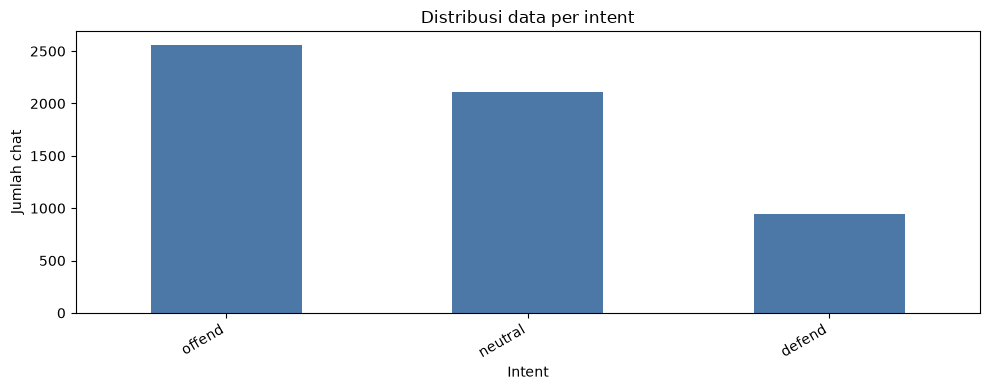

In [7]:
data_bersih, laporan_eda = run_eda()


## Split, Evaluasi, Penyimpanan Model, dan Prediksi


In [ ]:
# Menetapkan seed untuk pembagian data, cross-validation, dan training yang konsisten.
RANDOM_STATE = 42

# Folder penyimpanan model hasil training.
MODEL_DIR = Path("models/notebook_standalone")


In [ ]:
# Membagi data bersih menjadi data latih dan uji dengan proporsi intent tetap terwakili.
def _split_dataset(dataset_path, test_size = 0.2):
    data, data_report = load_clean_nlu_dataset(dataset_path)
    x_train, x_test, y_train, y_test = train_test_split(
        data["teks_chat"],
        data["label_intent"],
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=data["label_intent"],
    )
    return x_train, x_test, y_train, y_test, data_report


# Menyiapkan data latih, validasi, dan uji IndoBERT dengan data uji yang sama seperti model klasik.
def _split_transformer_dataset(dataset_path, validation_size = 0.15):
    """Pertahankan test 20% yang sama dengan SVM/NB; ambil validation dari train.

    validation_size adalah proporsi terhadap seluruh data (default 65/15/20).
    Indeks data bersih dipertahankan agar pemisahan dapat diaudit.
    """
    
    # Membaca dan membersihkan dataset sebelum membaginya.
    data, report = load_clean_nlu_dataset(dataset_path)

    # Menyisihkan 20% data test dengan seed dan stratifikasi yang sama seperti model klasik.
    x_pool, x_test, y_pool, y_test = train_test_split(
        data["teks_chat"], data["label_intent"],
        test_size=0.2, random_state=RANDOM_STATE,
        stratify=data["label_intent"],
    )

    # Mengambil validation dari pool train; default akhir menjadi 65% train, 15% validation, 20% test.
    x_train, x_val, y_train, y_val = train_test_split(
        x_pool, y_pool, test_size=validation_size / 0.8,
        random_state=RANDOM_STATE, stratify=y_pool,
    )
    return x_train, x_val, x_test, y_train, y_val, y_test, report

In [ ]:
# -----------------------------------------------------------------------------
# Evaluasi, penyimpanan model, dan prediksi model klasik.
# -----------------------------------------------------------------------------

# Mengukur accuracy dan F1 model pada data uji serta menampilkan laporan tiap kelas.
def _evaluate(model, x_test, y_test, title):
    # Memprediksi data uji lalu menghitung ukuran ketepatan model.
    y_pred = model.predict(x_test)
    metrics = {
        "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
        "f1_macro": round(float(f1_score(y_test, y_pred, average="macro", zero_division=0)), 4),
        "f1_weighted": round(float(f1_score(y_test, y_pred, average="weighted", zero_division=0)), 4),
        "classification_report": classification_report(y_test, y_pred, zero_division=0),
    }
    # Menampilkan metrik keseluruhan dan laporan per kelas.
    print(f"\n--- Evaluasi {title} (holdout test set) ---")
    print(f"Accuracy    : {metrics['accuracy']:.4f}")
    print(f"Macro F1    : {metrics['f1_macro']:.4f}")
    print(f"Weighted F1 : {metrics['f1_weighted']:.4f}")
    print(metrics["classification_report"])
    return metrics


# Menyimpan model klasik ke file agar dapat dipakai lagi untuk prediksi.
def _save_sklearn_model(model, model_dir, filename):
    output_dir = Path(model_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    model_path = output_dir / filename
    joblib.dump(model, model_path)
    print(f"Model tersimpan: {model_path}")
    return model_path


# Memuat model klasik pilihan, lalu mengembalikan prediksi intent dan confidence untuk satu chat.
def predict_intent(text, model_dir, filename):
    """Prediksi label dan confidence dari nama file model yang disebutkan eksplisit."""
    # Memastikan file model tersedia sebelum dimuat.
    
    model_path = Path(model_dir) / filename
    if not model_path.is_file():
        raise FileNotFoundError(f"File model tidak ditemukan: {model_path}. Periksa nama file dan folder model yang dipakai.")
    
    # Memuat model tersimpan dan memprediksi label chat.
    model = joblib.load(model_path)
    predicted = str(model.predict([str(text)])[0])
    # Menghitung confidence dari probabilitas jika tersedia, atau dari skor keputusan; jika keduanya tidak ada, memakai NaN.
    if hasattr(model, "predict_proba"):
        confidence = float(np.max(model.predict_proba([str(text)])[0]) * 100)
    elif hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function([str(text)]), dtype=float).reshape(1, -1)
        probabilities = np.exp(scores - scores.max(axis=1, keepdims=True))
        probabilities /= probabilities.sum(axis=1, keepdims=True)
        confidence = float(probabilities.max() * 100)
    else:
        confidence = float("nan")
    return predicted, round(confidence, 2)


# Mengemas model, metrik, laporan data, dan lokasi file dalam format hasil yang seragam.
def _result(
    model,
    metrics,
    report,
    model_path,
    **extra,
):
    """Samakan format hasil agar notebook dapat membandingkan semua model."""
    return {
        "model": model,
        "metrics": metrics,
        "data_report": report,
        "model_path": str(model_path),
        **extra,
    }

## Fungsi pendukung model klasik

Daftar parameter lama tetap tersedia: SVM 720 kombinasi, NB 1.920 kombinasi.
SVM memakai kalibrator sigmoid yang membungkus seluruh pipeline TF-IDF + LinearSVC,
dengan max_iter=10000. Struktur tersebut juga dipakai Optuna. Baseline SVM ikut
diperbaiki kalibrasinya; hasil lama tidak boleh dianggap hasil pipeline baru.

Grid Search mencoba semua kandidat pada 5-fold CV, refit pemenang, lalu evaluasi
test sekali. File cv_results.csv memuat mean/std/per-fold score, parameter, dan waktu.


In [ ]:
# Model klasik dijalankan pada CPU.
CLASSICAL_DEVICE = "cpu"

# Pilihan nilai C untuk tuning SVM; penjelasan ada di bawah.
SVM_C_VALUES = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 4.0, 8.0]

# Pilihan alpha untuk tuning Naive Bayes; penjelasan ada di bawah.
NB_ALPHA_VALUES = [0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.5, 1.0, 2.0]

# Batas maksimum iterasi solver LinearSVC untuk mencari solusi training.
SVM_MAX_ITER = 10000

In [ ]:
# Menyediakan pilihan parameter SVM atau Naive Bayes untuk Grid Search dan Optuna.
def _classical_search_spaces(model_kind):
    """Kembalikan grid baru agar mutasi satu eksperimen tidak mengubah lainnya."""
    common = {
        "tfidf__min_df": [1, 2],
        "tfidf__max_df": [0.95, 1.0],
        "tfidf__sublinear_tf": [True, False],
    }
    # Memilih ruang pencarian SVM, termasuk fitur kata atau karakter, nilai C, dan bobot kelas.
    if model_kind == "svm":
        return [
            {
                **deepcopy(common),
                "tfidf__analyzer": [analyzer],
                "tfidf__ngram_range": ngrams,
                "svm__C": list(SVM_C_VALUES),
                "svm__class_weight": [None, "balanced"],
            }
            for analyzer, ngrams in [
                ("word", [(1, 1), (1, 2), (1, 3)]),
                ("char_wb", [(3, 5), (3, 6)]),
            ]
        ]
    # Memilih ruang pencarian Naive Bayes, termasuk fitur kata, alpha, dan prior kelas.
    if model_kind == "nb":
        return [{
            **deepcopy(common),
            "tfidf__analyzer": ["word"],
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__use_idf": [True, False],
            "tfidf__norm": ["l2", "l1", None],
            "nb__alpha": list(NB_ALPHA_VALUES),
            "nb__fit_prior": [True, False],
        }]
    raise ValueError("model_kind harus 'svm' atau 'nb'.")


# Membuat pengubah teks menjadi fitur TF-IDF untuk model baseline.
def _baseline_tfidf():
    """Fitur baseline tetap; kalibrasi SVM memakai pipeline lengkap."""
    return TfidfVectorizer(
        ngram_range=(1, 2), min_df=1, max_df=0.98,
        sublinear_tf=True, strip_accents="unicode",
    )


# Menentukan jumlah pembagian data yang cukup untuk kalibrasi confidence SVM.
def _calibration_folds(y_train):
    folds = min(3, int(y_train.value_counts().min()))
    # Menolak kalibrasi jika data per kelas tidak cukup untuk dua fold.
    if folds < 2:
        raise ValueError("Setiap kelas perlu minimal 2 sampel untuk kalibrasi SVM.")
    return folds


# Membuat pipeline TF-IDF dan SVM dengan kalibrasi agar menghasilkan probabilitas kelas.
def _calibrated_linear_svm(
    c,
    class_weight = "balanced",
    calibration_cv = 3,
    *,
    vectorizer = None,
):
    """Kalibrasi sigmoid atas seluruh pipeline, termasuk vocabulary dan IDF."""
    # Menggabungkan pengubahan teks ke TF-IDF dan classifier SVM dalam satu pipeline.
    pipeline = Pipeline([
        ("tfidf", vectorizer if vectorizer is not None else TfidfVectorizer(
            strip_accents="unicode",
        )),
        ("svm", LinearSVC(
            C=c, class_weight=class_weight,
            random_state=RANDOM_STATE, max_iter=SVM_MAX_ITER,
        )),
    ])
    # Mengkalibrasi skor SVM dengan metode sigmoid pada pembagian data terpisah.
    return CalibratedClassifierCV(
        estimator=pipeline,
        method="sigmoid",
        cv=StratifiedKFold(
            n_splits=calibration_cv, shuffle=True, random_state=RANDOM_STATE,
        ),
        ensemble=True,
        n_jobs=1,  # Paralel hanya di CV luar, bukan di kedua tingkat sekaligus.
    )


# Membuat pipeline SVM atau Naive Bayes menggunakan parameter yang diberikan.
def _build_classical_model(
    model_kind, params, calibration_folds = 3,
):
    """Estimator identik untuk Grid Search, Optuna, dan refit pemenang."""
    # Memilih pipeline sesuai jenis model dan memasang parameter pencarian yang diberikan.
    if model_kind == "svm":
        model = _calibrated_linear_svm(1.0, None, calibration_folds)
        model.set_params(**{f"estimator__{key}": value for key, value in params.items()})
        return model
    if model_kind == "nb":
        return Pipeline([
            ("tfidf", TfidfVectorizer(strip_accents="unicode")),
            ("nb", MultinomialNB()),
        ]).set_params(**params)
    raise ValueError("model_kind harus 'svm' atau 'nb'.")




# Menyiapkan pembagian cross-validation dan jumlah fold kalibrasi SVM yang sesuai dengan data.
def _classical_cv(y_train, model_kind, cv_folds):
    """Bekukan fold luar; tentukan jumlah fold kalibrasi yang aman di dalamnya."""
    # Memastikan jumlah fold valid sebelum membuat pembagian cross-validation.
    if isinstance(cv_folds, bool) or not isinstance(cv_folds, int) or cv_folds < 2:
        raise ValueError("cv_folds harus bilangan bulat minimal 2.")
    # Menyesuaikan jumlah fold dengan jumlah sampel pada intent terkecil.
    smallest_class = int(y_train.value_counts().min())
    n_splits = min(cv_folds, smallest_class)
    if n_splits < 2:
        raise ValueError("Data train tiap intent perlu minimal 2 sampel untuk cross-validation.")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    folds = list(cv.split(np.zeros(len(y_train)), y_train))
    calibration_folds = 0
    # Untuk SVM, menyesuaikan fold kalibrasi dengan kelas terkecil di dalam data latih CV.
    if model_kind == "svm":
        minimum = min(int(y_train.iloc[a].value_counts().min()) for a, _ in folds)
        calibration_folds = min(3, minimum)
        if calibration_folds < 2:
            raise ValueError("Data per kelas tidak cukup untuk CV dan kalibrasi SVM.")
    return folds, calibration_folds


# Menyimpan ringkasan eksperimen, versi library, dan indeks pembagian data untuk pemeriksaan ulang.
def _save_search_report(run_dir, x_train, x_test, folds, summary):
    """Simpan audit split dan metadata; indeks merujuk pada dataset bersih."""
    # Mencatat versi library dan menyimpan ringkasan pencarian ke JSON.
    summary["environment"] = {
        "python": platform.python_version(), "sklearn": sklearn.__version__,
        "numpy": np.__version__, "pandas": pd.__version__,
    }
    (run_dir / "summary.json").write_text(
        json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8",
    )
    # Menyimpan indeks train, test, dan fold CV agar pembagiannya bisa diperiksa ulang.
    split = {
        "train": x_train.index.tolist(), "test": x_test.index.tolist(),
        "cv": [
            {
                "train": x_train.iloc[a].index.tolist(),
                "validation": x_train.iloc[b].index.tolist(),
            }
            for a, b in folds
        ],
    }
    (run_dir / "split_indices.json").write_text(
        json.dumps(split, indent=2), encoding="utf-8",
    )


## Baseline - SVM dan Naive Bayes

Fungsi training dengan parameter awal, tanpa pencarian parameter. Jalankan fungsi pendukung di atas terlebih dahulu.


In [ ]:
# Melatih SVM baseline, mengevaluasi data uji, lalu menyimpan modelnya.
def train_svm(dataset_path, model_dir, filename="intent_classifier_svm.pkl"):
    """Baseline SVM; kalibrasi ikut memisahkan TF-IDF pada fold internal."""
    # Menyiapkan data serta pipeline SVM sebelum pelatihan.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    model = _calibrated_linear_svm(
        c=2.0, calibration_cv=_calibration_folds(y_train), vectorizer=_baseline_tfidf(),
    )
    # Melatih model, mengukur hasil pada data uji, lalu menyimpannya.
    model.fit(x_train, y_train)
    metrics = _evaluate(model, x_test, y_test, "SVM baseline")
    path = _save_sklearn_model(model, model_dir, filename)
    return _result(model, metrics, report, path)


# Melatih Naive Bayes baseline, mengevaluasi data uji, lalu menyimpan modelnya.
def train_naive_bayes(dataset_path, model_dir, filename="intent_classifier_nb.pkl"):
    """Baseline TF-IDF + MultinomialNB, tanpa perubahan parameter lama."""
    # Menyiapkan data serta pipeline TF-IDF dan Naive Bayes.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    model = Pipeline([("tfidf", _baseline_tfidf()), ("nb", MultinomialNB(alpha=0.5))])
    # Melatih model, mengukur hasil pada data uji, lalu menyimpannya.
    model.fit(x_train, y_train)
    metrics = _evaluate(model, x_test, y_test, "Naive Bayes baseline")
    path = _save_sklearn_model(model, model_dir, filename)
    return _result(model, metrics, report, path)


## Tuning Grid Search - SVM dan Naive Bayes

Fungsi training yang mencoba seluruh kombinasi parameter dan memilih model berdasarkan macro-F1 cross-validation.


In [ ]:
# Mencoba semua kombinasi parameter dengan Grid Search, lalu mengevaluasi dan menyimpan model terbaik.
def _train_classical_grid(dataset_path, model_dir, filename, model_kind, cv_folds, n_jobs):
    """Coba seluruh grid pada train CV, refit pemenang, kemudian evaluasi test."""
    # Menyiapkan data, fold, pilihan parameter, dan folder hasil Grid Search.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    folds, calibration_folds = _classical_cv(y_train, model_kind, cv_folds)
    spaces = _classical_search_spaces(model_kind)
    prefix = "estimator__" if model_kind == "svm" else ""
    grid = [{prefix + key: values for key, values in space.items()} for space in spaces]
    model = _build_classical_model(model_kind, {}, calibration_folds)
    output_root = Path(model_dir) / "grid_results"
    output_root.mkdir(parents=True, exist_ok=True)
    run_dir = Path(tempfile.mkdtemp(prefix=f"{model_kind}_", dir=output_root))

    # Mencoba seluruh kombinasi dengan macro-F1 CV sebagai penentu model terbaik.
    search = GridSearchCV(
        model, grid, scoring="f1_macro", cv=folds, n_jobs=n_jobs,
        refit=True, verbose=1, error_score="raise", return_train_score=False,
    )
    started = perf_counter()
    search.fit(x_train, y_train)
    search_seconds = perf_counter() - started
    # Menyimpan hasil setiap kandidat dan mengambil parameter serta variasi skor kandidat terbaik.
    pd.DataFrame(search.cv_results_).to_csv(run_dir / "cv_results.csv", index=False)
    best = {key.removeprefix(prefix): value for key, value in search.best_params_.items()}
    cv_std = float(search.cv_results_["std_test_score"][search.best_index_])
    print("Parameter Grid Search terbaik:", best)
    print(f"Macro-F1 CV: {search.best_score_:.4f} +/- {cv_std:.4f}")

    # Tidak ada perubahan struktur estimator setelah pemilihan kandidat.
    model = search.best_estimator_
    metrics = _evaluate(model, x_test, y_test, f"{model_kind.upper()} Grid Search")
    path = _save_sklearn_model(model, model_dir, filename)
    # Merangkum konfigurasi, durasi, dan hasil evaluasi untuk laporan eksperimen.
    summary = {
        "method": "Grid Search", "model_kind": model_kind, "seed": RANDOM_STATE,
        "candidate_count": len(search.cv_results_["params"]),
        "cv_folds": len(folds), "calibration_folds": calibration_folds or None,
        "selection_metric": "cv_f1_macro", "test_used_for_selection": False,
        "best_params": best, "cv_f1_macro": float(search.best_score_), "cv_std": cv_std,
        "search_and_refit_seconds": search_seconds,
        "metrics": metrics, "data_report": report, "model_path": str(path),
    }
    _save_search_report(run_dir, x_train, x_test, folds, summary)
    return _result(
        model, metrics, report, path, best_params=best,
        cv_f1_macro=round(float(search.best_score_), 4), cv_std=cv_std,
        run_dir=str(run_dir), training_summary=summary,
    )


# Menjalankan pencarian parameter Grid Search khusus untuk SVM.
def train_svm_tuned(
    dataset_path, model_dir, filename="intent_classifier_svm_tuned.pkl",
    cv_folds=5, *, n_jobs=-1,
):
    """Grid Search SVM lengkap, termasuk kalibrasi pada setiap kandidat."""
    return _train_classical_grid(dataset_path, model_dir, filename, "svm", cv_folds, n_jobs)


# Menjalankan pencarian parameter Grid Search khusus untuk Naive Bayes.
def train_naive_bayes_tuned(
    dataset_path, model_dir, filename="intent_classifier_nb_tuned.pkl",
    cv_folds=5, *, n_jobs=-1,
):
    """Grid Search MultinomialNB; semua pilihan lama dipertahankan."""
    return _train_classical_grid(dataset_path, model_dir, filename, "nb", cv_folds, n_jobs)


## Tuning Optuna - SVM dan Naive Bayes

Optuna memakai pilihan diskret, estimator, dan fold yang sama dengan Grid Search.
TPE tidak mencoba seluruh kombinasi dan bisa mengulang kandidat. Default: 100 trial
COMPLETE awal, lalu patience 30 dengan min_delta 0,001 (0,1 poin persentase).
Pada trial ke-100 skor terbaik menjadi acuan; penghitung stagnasi mulai sesudahnya.
Tanpa peningkatan bermakna, berhenti paling awal setelah 130 trial selesai.
Kenaikan kecil terakumulasi terhadap acuan; pemenang tetap skor tertinggi sebenarnya.

Batas 500 adalah jumlah percobaan maksimum, bukan jaminan optimum. Timeout opsional
boleh mengakhiri lebih awal. FAIL/PRUNED tidak dihitung sebagai stagnasi; error training
ditampilkan dan riwayat disimpan. Ini penghentian study, bukan pruning training kandidat.
Masing-masing trial menyelesaikan semua fold. Riwayat CSV untuk audit, bukan resume study.


### Pengaturan dan fungsi pendukung Optuna

Menyiapkan batas trial, penghentian stagnasi, dan pemilihan parameter.


In [ ]:
# Batas trial dan aturan berhenti Optuna saat skor tidak membaik.
OPTUNA_MIN_TRIALS = 100
OPTUNA_PATIENCE = 30
OPTUNA_MIN_DELTA = 0.001
OPTUNA_MAX_TRIALS = 500
OPTUNA_TIMEOUT = None  # Bila diisi, timeout boleh menghentikan sebelum 100 trial.

# Membuat model Optuna melalui pembuat pipeline yang juga dipakai Grid Search.
def _build_optuna_model(
    model_kind, params, calibration_folds = 3,
):
    """Alias kompatibilitas; kedua pencarian memakai builder yang sama."""
    return _build_classical_model(model_kind, params, calibration_folds)


class OptunaStagnationStopper:
    """Hentikan study setelah fase awal dan beberapa trial COMPLETE stagnan.

    Setelah min_trials selesai, skor terbaik menjadi acuan. Peningkatan kecil
    dapat terakumulasi terhadap acuan tersebut. Patience baru dihitung setelah
    fase awal; FAIL/PRUNED tidak dihitung. Pemilihan model tetap memakai best
    trial sebenarnya, bukan skor acuan penghentian.
    """

    # Menyiapkan batas trial awal, toleransi stagnasi, dan penghitung untuk penghentian Optuna.
    def __init__(self, min_trials=100, patience=30, min_delta=0.001):
        # Memastikan jumlah trial, patience, dan ambang peningkatan memiliki nilai yang valid.
        for name, value in {"min_trials": min_trials, "patience": patience}.items():
            if isinstance(value, bool) or not isinstance(value, int) or value < 1:
                raise ValueError(f"{name} harus bilangan bulat positif.")
        if not math.isfinite(min_delta) or min_delta < 0:
            raise ValueError("min_delta harus nonnegatif dan finite.")
        # Menginisialisasi pengaturan dan penghitung sebelum pencarian dimulai.
        self.min_trials = min_trials
        self.patience = patience
        self.min_delta = min_delta
        self.completed = 0
        self.stale_trials = 0
        self.reference_best = None
        self.stop_reason = None

    # Memperbarui perkembangan skor setiap trial dan menghentikan Optuna bila terlalu lama tidak meningkat.
    def __call__(self, study, trial):
        # Mengabaikan trial yang belum selesai atau tidak menghasilkan skor yang valid.
        if trial.state.name != "COMPLETE" or trial.value is None:
            return
        if not math.isfinite(trial.value):
            return
        # Menghitung trial selesai dan mengambil skor terbaik sejauh ini.
        self.completed += 1
        best = float(study.best_value)
        # Selama fase awal, memperbarui skor acuan tanpa menghitung stagnasi.
        if self.completed <= self.min_trials:
            self.reference_best = best
            self.stale_trials = 0
            phase = f"fase awal {self.completed}/{self.min_trials}"
        else:
            gain = best - self.reference_best
            # Mereset penghitung jika peningkatan cukup besar; selain itu menambah jumlah trial stagnan.
            if gain > 0 and gain + 1e-12 >= self.min_delta:
                self.reference_best = best
                self.stale_trials = 0
            else:
                self.stale_trials += 1
            phase = f"stagnasi {self.stale_trials}/{self.patience}"
            # Menghentikan pencarian ketika jumlah trial stagnan mencapai patience.
            if self.stale_trials >= self.patience:
                self.stop_reason = "stagnation"
                study.stop()
        # Mencatat status penghentian dan menampilkan perkembangan pencarian.
        study.set_user_attr("stopping_state", self.state())
        print(f"Trial selesai={self.completed} | best CV={best:.6f} | {phase}", flush=True)

    # Mengembalikan jumlah trial dan status penghentian untuk dicatat dalam laporan.
    def state(self):
        return {
            "completed": self.completed, "stale_trials": self.stale_trials,
            "reference_best": self.reference_best, "stop_reason": self.stop_reason,
        }


# Meminta Optuna memilih satu kombinasi parameter dari pilihan yang tersedia.
def _suggest_optuna_params(trial, model_kind):
    """TPE memilih nilai diskret yang sama persis dengan Grid Search."""
    spaces = _classical_search_spaces(model_kind)
    # Memilih jenis fitur SVM; Naive Bayes memakai fitur kata.
    if model_kind == "svm":
        analyzers = [space["tfidf__analyzer"][0] for space in spaces]
        analyzer = trial.suggest_categorical("analyzer", analyzers)
        space = next(s for s in spaces if s["tfidf__analyzer"] == [analyzer])
    else:
        analyzer, space = "word", spaces[0]
    params = {"tfidf__analyzer": analyzer}
    # Optuna menyimpan kategori primitif; tuple n-gram dikodekan sebagai string.
    # Nama n-gram berbeda per analyzer agar distribution tidak berubah antar-trial.
    choices = [f"{low},{high}" for low, high in space["tfidf__ngram_range"]]
    encoded = trial.suggest_categorical(f"{analyzer}_ngram_range", choices)
    params["tfidf__ngram_range"] = tuple(map(int, encoded.split(",")))
    # Memilih nilai untuk parameter lain yang belum ditentukan.
    for key, choices in space.items():
        if key not in {"tfidf__analyzer", "tfidf__ngram_range"}:
            params[key] = trial.suggest_categorical(key, choices)
    return params


### Fungsi training Optuna

Menjalankan pencarian parameter, melatih kandidat terbaik, dan mengevaluasi hasilnya.


In [ ]:
# Mencari parameter dengan Optuna, melatih ulang kandidat terbaik, lalu mengevaluasi dan menyimpan hasil.
def _train_classical_optuna(
    dataset_path, model_dir, filename, *, model_kind, n_trials, cv_folds,
    timeout, n_jobs, min_trials, patience, min_delta,
):
    """TPE pada train CV; berhenti adaptif, refit best, lalu evaluasi test."""

    # Menyiapkan penghentian otomatis serta memeriksa batas trial, timeout, dan jumlah proses CV.
    stopper = OptunaStagnationStopper(min_trials, patience, min_delta)
    if isinstance(n_trials, bool) or not isinstance(n_trials, int) or n_trials < min_trials:
        raise ValueError("n_trials (batas maksimum) harus integer >= min_trials.")
    if timeout is not None and (not math.isfinite(timeout) or timeout <= 0):
        raise ValueError("timeout harus positif atau None.")
    if isinstance(n_jobs, bool) or not isinstance(n_jobs, int) or n_jobs == 0:
        raise ValueError("n_jobs harus integer selain 0.")

    # Menyiapkan pembagian data dan folder penyimpanan hasil Optuna.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    folds, calibration_folds = _classical_cv(y_train, model_kind, cv_folds)
    output_root = Path(model_dir) / "optuna_results"
    output_root.mkdir(parents=True, exist_ok=True)
    run_dir = Path(tempfile.mkdtemp(prefix=f"{model_kind}_", dir=output_root))
    # Membuat pencarian TPE yang memaksimalkan macro-F1 tanpa memangkas trial di tengah evaluasi.
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.NopPruner(),  # Satu kandidat dinilai dengan semua fold.
        study_name=f"{model_kind}_macro_f1",
    )

    # Mengukur rata-rata macro-F1 cross-validation untuk satu kombinasi parameter yang dicoba Optuna.
    def objective(trial):
        params = _suggest_optuna_params(trial, model_kind)
        # Catat konfigurasi juga bila training kandidat gagal.
        trial.set_user_attr("pipeline_params", params)
        model = _build_classical_model(model_kind, params, calibration_folds)
        # Menilai kandidat pada seluruh fold dan menolak skor yang tidak valid.
        scores = cross_val_score(
            model, x_train, y_train, cv=folds, scoring="f1_macro",
            n_jobs=n_jobs, error_score="raise",
        )
        if not np.all(np.isfinite(scores)):
            raise ValueError("Skor CV tidak finite; periksa dataset dan kandidat.")
        trial.set_user_attr("fold_scores", scores.tolist())
        trial.set_user_attr("cv_std", float(scores.std()))
        return float(scores.mean())

    # Memeriksa kondisi berhenti dan menyimpan riwayat setelah satu trial Optuna selesai.
    def after_trial(study, trial):
        stopper(study, trial)
        study.trials_dataframe().to_csv(run_dir / "trials.csv", index=False)

    print(
        f"Optuna {model_kind.upper()}: minimal {min_trials} COMPLETE, "
        f"patience={patience}, delta={min_delta}, maksimal {n_trials} trial."
    )
    started = perf_counter()
    # Trial berurutan untuk reproducibility; hanya fold CV yang paralel.
    # Kesalahan training tidak disembunyikan. Riwayat tetap disimpan di finally.
    try:
        study.optimize(
            objective, n_trials=n_trials, timeout=timeout,
            n_jobs=1, callbacks=[after_trial],
        )
    finally:
        study.trials_dataframe().to_csv(run_dir / "trials.csv", index=False)
    # Mencatat durasi, alasan berhenti, dan parameter kandidat dengan skor terbaik.
    search_seconds = perf_counter() - started
    reason = stopper.stop_reason or (
        "max_trials" if len(study.trials) >= n_trials else "timeout"
    )
    best = dict(study.best_trial.user_attrs["pipeline_params"])
    best["tfidf__ngram_range"] = tuple(best["tfidf__ngram_range"])
    print(f"Berhenti: {reason}; best macro-F1 CV={study.best_value:.6f}")
    print("Parameter terbaik:", best)

    # Best trial tetap dipilih, termasuk peningkatan terakhir yang < min_delta.
    model = _build_classical_model(model_kind, best, calibration_folds)
    model.fit(x_train, y_train)
    metrics = _evaluate(model, x_test, y_test, f"{model_kind.upper()} Optuna")
    path = _save_sklearn_model(model, model_dir, filename)
    # Merangkum jumlah trial, parameter, skor, dan status penghentian untuk laporan.
    summary = {
        "method": "Optuna TPE", "search_space": "same_discrete_grid",
        "model_kind": model_kind, "seed": RANDOM_STATE,
        "optuna_version": optuna.__version__,
        "max_trials": n_trials, "min_trials": min_trials,
        "patience": patience, "min_delta": min_delta,
        "n_trials_attempted": len(study.trials),
        "n_trials_completed": stopper.completed,
        "unique_candidates": len({
            json.dumps(t.user_attrs.get("pipeline_params", {}), sort_keys=True)
            for t in study.trials if t.state.name == "COMPLETE"
        }),
        "stop_reason": reason, "stopping_state": stopper.state(),
        "timeout": timeout, "search_seconds": search_seconds,
        "cv_folds": len(folds), "calibration_folds": calibration_folds or None,
        "selection_metric": "cv_f1_macro", "test_used_for_selection": False,
        "best_trial": study.best_trial.number,
        "best_params": best, "cv_f1_macro": float(study.best_value),
        "cv_std": float(study.best_trial.user_attrs["cv_std"]),
        "metrics": metrics, "data_report": report, "model_path": str(path),
    }
    _save_search_report(run_dir, x_train, x_test, folds, summary)
    return _result(
        model, metrics, report, path, best_params=best,
        cv_f1_macro=round(float(study.best_value), 4), cv_std=summary["cv_std"],
        study=study, run_dir=str(run_dir), training_summary=summary,
    )


# Menjalankan pencarian parameter Optuna khusus untuk Naive Bayes.
def train_naive_bayes_optuna(
    dataset_path, model_dir, filename="intent_classifier_nb_optuna.pkl", *,
    n_trials=500, cv_folds=5, timeout=None, n_jobs=-1,
    min_trials=100, patience=30, min_delta=0.001,
):
    """NB Optuna: 100 trial awal, lalu stop stagnasi; batas cadangan 500."""
    return _train_classical_optuna(
        dataset_path, model_dir, filename, model_kind="nb", n_trials=n_trials,
        cv_folds=cv_folds, timeout=timeout, n_jobs=n_jobs,
        min_trials=min_trials, patience=patience, min_delta=min_delta,
    )


# Menjalankan pencarian parameter Optuna khusus untuk SVM.
def train_svm_optuna(
    dataset_path, model_dir, filename="intent_classifier_svm_optuna.pkl", *,
    n_trials=500, cv_folds=5, timeout=None, n_jobs=-1,
    min_trials=100, patience=30, min_delta=0.001,
):
    """SVM Optuna dengan estimator/fold/parameter sama dengan Grid Search."""
    return _train_classical_optuna(
        dataset_path, model_dir, filename, model_kind="svm", n_trials=n_trials,
        cv_folds=cv_folds, timeout=timeout, n_jobs=n_jobs,
        min_trials=min_trials, patience=patience, min_delta=min_delta,
    )


## DEFINISI 5 — fine-tuning dan inferensi IndoBERT

**Audit:** alur full fine-tuning yang lama sudah memisahkan test, memilih checkpoint
berdasarkan validation macro-F1, memakai early stopping, dan mengulang dari pretrained
serta seed yang sama pada setiap learning rate. Mekanisme itu dipertahankan.

Salinan ini menetapkan AdamW secara eksplisit, memilih mixed precision sesuai perangkat,
mencatat presisi/versi, membersihkan cache model lama sebelum retraining, serta menyimpan
split, loss, metrik per epoch, checkpoint, dan prediksi test. Evaluasi/save sama-sama per epoch.
Batas 12 epoch bukan jaminan optimal; lihat riwayat validation. Confidence softmax IndoBERT
belum dikalibrasi dan tidak dianggap jaminan kebenaran. Ketimpangan kelas belum otomatis
menggunakan weighted loss; perubahan itu memerlukan eksperimen validation tersendiri.

Default mengandalkan pretrained di cache lokal; ubah local_files_only=False hanya jika
memang ingin mengunduh model. Checkpoint save_only_model=True tidak menyimpan optimizer
untuk resume training. Untuk memakai presisi seperti run lama, pilih precision='fp16' pada CUDA;
pilihan auto dapat memakai BF16 dan menghasilkan angka berbeda.

Referensi: [Hugging Face Trainer 4.46.3](https://huggingface.co/docs/transformers/v4.46.3/en/main_classes/trainer),
[EarlyStoppingCallback](https://huggingface.co/docs/transformers/v4.46.3/en/main_classes/callback).


In [ ]:
# Perangkat dan pengaturan fine-tuning IndoBERT.
TRANSFORMER_DEVICE = "cuda"  # Ganti cpu jika GPU CUDA tidak tersedia.
TRANSFORMER_EPOCHS = 12
TRANSFORMER_OPTIONS = {
    "learning_rates": (1e-5, 2e-5, 3e-5),
    "validation_size": 0.15,
    "batch_size": 8,
    "eval_batch_size": 16,
    "gradient_accumulation_steps": 2,
    "max_length": 128,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "lr_scheduler_type": "linear",
    "dropout": 0.1,
    "label_smoothing_factor": 0.0,
    "max_grad_norm": 1.0,
    "early_stopping_patience": 3,
    "early_stopping_threshold": 0.001,
    "gradient_checkpointing": False,
    "precision": "auto",  # CUDA: BF16 jika tersedia, selain itu FP16; CPU: FP32.
    "local_files_only": True,  # Model pralatih harus sudah ada di cache lokal.
}

# Melatih IndoBERT, memilih model berdasarkan data validasi, lalu mengevaluasi data uji dan menyimpan hasil.
def train_transformer(
    dataset_path,
    model_dir,
    model_name = "indobenchmark/indobert-base-p1",
    epochs = 12,
    max_length = 128,
    learning_rate = 2e-5,
    device = "cuda",
    *,
    learning_rates = None,
    validation_size = 0.15,
    batch_size = 8,
    eval_batch_size = 16,
    gradient_accumulation_steps = 2,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    lr_scheduler_type = "linear",
    dropout = 0.1,
    label_smoothing_factor = 0.0,
    max_grad_norm = 1.0,
    early_stopping_patience = 3,
    early_stopping_threshold = 0.001,
    gradient_checkpointing = False,
    precision = "auto",
    local_files_only = True,
):
    """Full fine-tuning IndoBERT, seleksi validation, lalu satu evaluasi test.

    ``epochs`` adalah batas maksimum; early stopping memantau validation
    macro-F1. ``learning_rates`` mengaktifkan pencarian LR, setiap trial mulai
    dari pretrained dan seed yang sama. Jika None, gunakan ``learning_rate``.
    Test 20% identik dengan model klasik; validation 15% diambil dari pool train.
    Checkpoint dan riwayat setiap run disimpan terpisah untuk audit eksperimen.
    """



    # Mixed precision hanya untuk GPU; auto memilih BF16 bila didukung.
    precision = str(precision).lower()
    if precision not in {"auto", "fp32", "fp16", "bf16"}:
        raise ValueError("precision harus auto/fp32/fp16/bf16.")

    # Memastikan perangkat CPU atau CUDA tersedia dan mendukung presisi yang dipilih.
    device = str(device).strip().lower()
    if device not in {"cpu", "cuda"}:
        raise ValueError("device harus 'cpu' atau 'cuda'.")
    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("device='cuda' dipilih, tetapi CUDA tidak tersedia.")
    if device == "cpu" and precision in {"fp16", "bf16"}:
        raise ValueError("Gunakan precision='fp32' atau 'auto' untuk CPU.")
    effective_precision = precision
    # Menentukan presisi otomatis sesuai kemampuan perangkat.
    if precision == "auto":
        effective_precision = (
            "bf16" if device == "cuda" and torch.cuda.is_bf16_supported()
            else "fp16" if device == "cuda" else "fp32"
        )
    if effective_precision == "bf16" and not torch.cuda.is_bf16_supported():
        raise ValueError("GPU tidak mendukung BF16; pilih fp16 atau auto.")
    # Buang model inferensi lama dari cache sebelum mengalokasikan model training.
    for key in list(_TRANSFORMER_INFERENCE_CACHE):
        if key[0] == str((Path(model_dir) / "intent_classifier_transformer").resolve()):
            del _TRANSFORMER_INFERENCE_CACHE[key]
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

    # Memastikan jumlah epoch, ukuran batch, dan batas training berupa bilangan bulat positif.
    for name, value in {
        "epochs": epochs, "max_length": max_length, "batch_size": batch_size,
        "eval_batch_size": eval_batch_size,
        "gradient_accumulation_steps": gradient_accumulation_steps,
        "early_stopping_patience": early_stopping_patience,
    }.items():
        if not isinstance(value, int) or isinstance(value, bool) or value < 1:
            raise ValueError(f"{name} harus bilangan bulat positif.")
    # Menyiapkan daftar learning rate dan memeriksa rentang nilai pengaturan training.
    rates = list(dict.fromkeys(learning_rates if learning_rates is not None else [learning_rate]))
    if not rates or any(not math.isfinite(rate) or rate <= 0 for rate in rates):
        raise ValueError("learning rate harus positif dan daftar trial tidak boleh kosong.")
    if not 0 <= dropout < 1 or not 0 <= label_smoothing_factor < 1:
        raise ValueError("dropout dan label_smoothing_factor harus di rentang [0, 1).")
    if not 0 <= warmup_ratio <= 1 or not math.isfinite(weight_decay) or weight_decay < 0:
        raise ValueError("warmup_ratio harus di [0, 1] dan weight_decay harus nonnegatif.")
    if not math.isfinite(max_grad_norm) or max_grad_norm <= 0:
        raise ValueError("max_grad_norm harus positif.")
    if not math.isfinite(early_stopping_threshold) or early_stopping_threshold < 0:
        raise ValueError("early_stopping_threshold harus nonnegatif.")

    # Membagi data menjadi train, validation, dan test; mengubah label intent menjadi angka.
    x_train, x_val, x_test, y_train, y_val, y_test, report = _split_transformer_dataset(
        dataset_path, validation_size,
    )
    encoder = LabelEncoder().fit(y_train)
    labels = encoder.classes_.tolist()
    y_test_encoded = encoder.transform(y_test)
    id2label = dict(enumerate(labels))
    label2id = {label: index for index, label in id2label.items()}
    # Memuat tokenizer dan memeriksa batas panjang token.
    tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=local_files_only)
    if max_length > tokenizer.model_max_length:
        raise ValueError(f"max_length melebihi kapasitas tokenizer: {tokenizer.model_max_length}.")

    # Mengubah chat menjadi token dan label menjadi angka dalam format dataset untuk IndoBERT.
    def make_dataset(texts, actual):
        dataset = Dataset.from_dict({"teks_chat": texts.tolist(), "labels": encoder.transform(actual).tolist()})
        return dataset.map(
            lambda examples: tokenizer(examples["teks_chat"], truncation=True, max_length=max_length),
            batched=True, remove_columns=["teks_chat"],
        )

    # Menyiapkan token data latih dan validasi serta padding untuk setiap batch.
    train_dataset = make_dataset(x_train, y_train)
    validation_dataset = make_dataset(x_val, y_val)
    collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8 if device == "cuda" else None)
    # Membuat folder run terpisah dan menyimpan indeks pembagian data.
    output_root = Path(model_dir) / "transformer_results"
    output_root.mkdir(parents=True, exist_ok=True)
    output_dir = Path(tempfile.mkdtemp(prefix="run_", dir=output_root)).resolve()
    split_indices = {
        name: texts.index.tolist()
        for name, texts in (("train", x_train), ("validation", x_val), ("test", x_test))
    }
    (output_dir / "split_indices.json").write_text(json.dumps(split_indices, indent=2), encoding="utf-8")

    # Menghitung accuracy, macro-F1, dan weighted-F1 dari prediksi saat evaluasi IndoBERT.
    def compute_metrics(eval_prediction):
        logits, actual = eval_prediction
        predicted = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(actual, predicted),
            "f1_macro": f1_score(actual, predicted, average="macro", zero_division=0),
            "f1_weighted": f1_score(actual, predicted, average="weighted", zero_division=0),
        }

    trial_results = []
    # Mencoba setiap learning rate dari model pralatih dan seed yang sama.
    for trial_index, rate in enumerate(rates, start=1):
        set_seed(RANDOM_STATE)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=len(labels), id2label=id2label, label2id=label2id,
            hidden_dropout_prob=dropout, attention_probs_dropout_prob=dropout,
            classifier_dropout=dropout, local_files_only=local_files_only,
        )
        if max_length > model.config.max_position_embeddings:
            raise ValueError("max_length melebihi max_position_embeddings model.")
        # Full fine-tuning: seluruh encoder dan classification head dilatih.
        model.requires_grad_(True)
        model.config.nlu_max_length = max_length
        # Mengatur training, evaluasi per epoch, dan penyimpanan checkpoint dengan macro-F1 validasi terbaik.
        training_args = TrainingArguments(
            output_dir=str(output_dir / f"trial_{trial_index}"),
            eval_strategy="epoch", save_strategy="epoch", logging_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
            learning_rate=rate, per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=eval_batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,
            num_train_epochs=epochs, weight_decay=weight_decay, warmup_ratio=warmup_ratio,
            lr_scheduler_type=lr_scheduler_type, label_smoothing_factor=label_smoothing_factor,
            max_grad_norm=max_grad_norm, gradient_checkpointing=gradient_checkpointing,
            save_total_limit=1, save_only_model=True, report_to="none",
            disable_tqdm=True,
            seed=RANDOM_STATE, data_seed=RANDOM_STATE, dataloader_num_workers=0,
            use_cpu=device == "cpu",
            fp16=effective_precision == "fp16",
            bf16=effective_precision == "bf16",
            optim="adamw_torch",
        )
        # Menyiapkan Trainer dengan penghentian otomatis saat skor validasi tidak membaik.
        trainer = Trainer(
            model=model, args=training_args, train_dataset=train_dataset,
            eval_dataset=validation_dataset, processing_class=tokenizer,
            data_collator=collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(
                early_stopping_patience=early_stopping_patience,
                early_stopping_threshold=early_stopping_threshold,
            )],
        )
        print(
            f"Transformer trial {trial_index}/{len(rates)} | {model_name} | {device.upper()} | "
            f"train={len(x_train)} val={len(x_val)} test={len(x_test)} | "
            f"max_epoch={epochs} lr={rate:g} effective_batch="
            f"{batch_size * gradient_accumulation_steps * training_args.world_size}",
            flush=True,
        )
        # Menjalankan fine-tuning untuk learning rate pada trial ini.
        trainer.train()
        history = trainer.state.log_history
        eval_history = [row for row in history if "eval_f1_macro" in row]
        best_eval = max(eval_history, key=lambda row: row["eval_f1_macro"])
        trial_result = {
            "trial": trial_index, "learning_rate": rate,
            "best_validation_f1_macro": float(trainer.state.best_metric),
            "best_epoch": float(best_eval["epoch"]),
            "epochs_trained": float(trainer.state.epoch),
            "best_checkpoint": trainer.state.best_model_checkpoint,
            "history": history,
        }
        trial_results.append(trial_result)
        (output_dir / "trials.json").write_text(json.dumps(trial_results, indent=2), encoding="utf-8")
        print(f"Trial {trial_index}: best epoch={best_eval['epoch']}, val macro-F1={trainer.state.best_metric:.4f}", flush=True)
        # Hanya satu model/optimizer di GPU selama pencarian.
        del trainer, model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

    # Memuat checkpoint dari trial dengan macro-F1 validasi tertinggi untuk evaluasi akhir.
    best_trial = max(trial_results, key=lambda row: row["best_validation_f1_macro"])
    model = AutoModelForSequenceClassification.from_pretrained(best_trial["best_checkpoint"], local_files_only=True)
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir=str(output_dir / "evaluation"), per_device_eval_batch_size=eval_batch_size,
            report_to="none", use_cpu=device == "cpu", dataloader_num_workers=0,
            disable_tqdm=True,
        ),
        processing_class=tokenizer, data_collator=collator,
    )
    # Test baru diprediksi setelah semua trial selesai dan pemenang terkunci.
    prediction_output = trainer.predict(make_dataset(x_test, y_test))
    y_pred = np.argmax(prediction_output.predictions, axis=-1)
    metrics = {
        "accuracy": round(float(accuracy_score(y_test_encoded, y_pred)), 4),
        "f1_macro": round(float(f1_score(y_test_encoded, y_pred, average="macro", zero_division=0)), 4),
        "f1_weighted": round(float(f1_score(y_test_encoded, y_pred, average="weighted", zero_division=0)), 4),
        "classification_report": classification_report(
            y_test_encoded, y_pred, labels=list(id2label), target_names=labels, zero_division=0,
        ),
        "confusion_matrix": confusion_matrix(y_test_encoded, y_pred, labels=list(id2label)).tolist(),
        "labels": labels,
    }
    # Mengumpulkan konfigurasi, pembagian data, serta riwayat trial dalam laporan training.
    summary = {
        "model_name": model_name, "seed": RANDOM_STATE,
        "torch_version": torch.__version__, "transformers_version": transformers.__version__,
        "device": device, "max_epochs": epochs, "max_length": max_length,
        "precision": effective_precision, "optimizer": "adamw_torch",
        "python_version": platform.python_version(),
        "full_fine_tuning": True, "local_files_only": local_files_only,
        "batch_size": batch_size, "eval_batch_size": eval_batch_size,
        "gradient_accumulation_steps": gradient_accumulation_steps,
        "effective_batch_size": batch_size * gradient_accumulation_steps * training_args.world_size,
        "weight_decay": weight_decay, "warmup_ratio": warmup_ratio,
        "lr_scheduler_type": lr_scheduler_type, "dropout": dropout,
        "label_smoothing_factor": label_smoothing_factor, "max_grad_norm": max_grad_norm,
        "gradient_checkpointing": gradient_checkpointing,
        "early_stopping_patience": early_stopping_patience,
        "early_stopping_threshold": early_stopping_threshold,
        "split_sizes": {name: len(indices) for name, indices in split_indices.items()},
        "validation_size": validation_size, "data_report": report,
        "selection_metric": "validation_f1_macro", "test_used_for_selection": False,
        "best_trial": {key: value for key, value in best_trial.items() if key != "history"},
        "trials": trial_results, "run_dir": str(output_dir),
    }
    # Menampilkan skor evaluasi akhir model terpilih.
    print("\n--- Evaluasi Transformer (test; seleksi hanya dari validation) ---")
    print(f"Best LR: {best_trial['learning_rate']:g} | best epoch: {best_trial['best_epoch']}")
    print(f"Accuracy: {metrics['accuracy']:.4f} | Macro F1: {metrics['f1_macro']:.4f}")
    print(metrics["classification_report"])

    # Menyimpan model, tokenizer, label encoder, dan laporan agar bisa digunakan kembali.
    final_dir = Path(model_dir) / "intent_classifier_transformer"
    trainer.save_model(str(final_dir))
    tokenizer.save_pretrained(str(final_dir))
    joblib.dump(encoder, final_dir / "label_encoder.pkl")
    for name, payload in (("metrics.json", metrics), ("training_summary.json", summary)):
        (final_dir / name).write_text(json.dumps(payload, indent=2), encoding="utf-8")
        (output_dir / name).write_text(json.dumps(payload, indent=2), encoding="utf-8")
    # Menyimpan prediksi data uji beserta label aslinya untuk analisis kesalahan.
    predictions = x_test.to_frame(name="teks_chat")
    predictions["actual"] = y_test.to_numpy()
    predictions["predicted"] = encoder.inverse_transform(y_pred)
    predictions.to_csv(final_dir / "test_predictions.csv", index_label="clean_row_index")
    # Notebook dapat melakukan retraining tanpa restart kernel; buang cache model lama.
    for key in list(_TRANSFORMER_INFERENCE_CACHE):
        if key[0] == str(final_dir.resolve()):
            del _TRANSFORMER_INFERENCE_CACHE[key]
    print(f"Model Transformer tersimpan: {final_dir}")
    return _result(
        model, metrics, report, final_dir, tokenizer=tokenizer,
        label_encoder=encoder, training_summary=summary,
    )


# Cache model dan tokenizer untuk prediksi IndoBERT berulang.
_TRANSFORMER_INFERENCE_CACHE = {}


# Memprediksi intent satu chat dengan IndoBERT tersimpan dan mengembalikan confidence-nya.
def predict_transformer_intent(
    text,
    model_dir,
    device = "cuda",
):
    """Prediksi satu chat dengan Transformer hasil fine-tuning.

    Fungsi ini dipisahkan dari training agar sel uji notebook dapat menguji
    chat baru pada model Transformer dengan format yang sama seperti model
    klasik: ``(label_intent, confidence_persen)``.
    """

    # Memastikan perangkat inferensi valid dan tersedia.
    requested_device = str(device).strip().lower()
    if requested_device not in {"cpu", "cuda"}:
        raise ValueError("device harus 'cpu' atau 'cuda'.")
    if requested_device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("device='cuda' dipilih, tetapi CUDA tidak tersedia.")

    # Memastikan folder model hasil training tersedia sebelum prediksi.
    saved_model_dir = Path(model_dir) / "intent_classifier_transformer"
    if not saved_model_dir.is_dir():
        raise FileNotFoundError(
            "Model Transformer belum tersedia. Jalankan train_transformer_model() terlebih dahulu: "
            f"{saved_model_dir}"
        )

    # Memuat model dan tokenizer hanya jika belum ada di cache untuk lokasi dan perangkat ini.
    cache_key = (str(saved_model_dir.resolve()), requested_device)
    if cache_key not in _TRANSFORMER_INFERENCE_CACHE:
        runtime_device = torch.device(requested_device)
        tokenizer = AutoTokenizer.from_pretrained(saved_model_dir, local_files_only=True)
        model = AutoModelForSequenceClassification.from_pretrained(saved_model_dir, local_files_only=True)
        model.to(runtime_device)
        model.eval()
        _TRANSFORMER_INFERENCE_CACHE[cache_key] = (tokenizer, model)
    # Mengambil model dari cache dan mengubah chat menjadi token pada perangkat yang sama.
    tokenizer, model = _TRANSFORMER_INFERENCE_CACHE[cache_key]
    runtime_device = next(model.parameters()).device
    encoded = tokenizer(
        str(text), return_tensors="pt", truncation=True,
        max_length=getattr(model.config, "nlu_max_length", 128),
    )
    encoded = {name: value.to(runtime_device) for name, value in encoded.items()}
    # Menghitung probabilitas tiap intent tanpa menyimpan gradien training.
    with torch.inference_mode():
        probabilities = torch.softmax(model(**encoded).logits, dim=-1)[0]
    # Memilih intent dengan probabilitas tertinggi dan mengubah confidence menjadi persen.
    label_index = int(torch.argmax(probabilities).item())
    labels = model.config.id2label
    label = labels.get(label_index, labels.get(str(label_index), str(label_index)))
    confidence = round(float(probabilities[label_index].item() * 100), 2)
    return str(label), confidence




## DEFINISI 6 — fungsi pemanggil dan ringkasan eksperimen

Helper menampilkan metrik test dan 10 contoh chat secara terpisah. Durasi meliputi
pencarian/pelatihan, evaluasi, dan penyimpanan; bukan latensi satu chat.
Fungsi prediksi lokal menerima model_dir secara eksplisit agar nama fungsi tidak tertimpa wrapper.


In [ ]:
# Contoh chat dan label yang diharapkan untuk evaluasi tambahan.
HOSTAGE_TEST_CASES = [
    ("offend", "B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman."),
    ("defend", "Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik."),
    ("defend", "Aku Spy dan semalam Guard Raka, jadi jangan curigai dia."),
    ("neutral", "Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?"),
    ("offend", "Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya."),
    ("offend", "Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam."),
    ("defend", "Klaimku Civilian, jadi aku memang tidak memiliki aksi malam."),
    ("neutral", "Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi."),
    ("offend", "A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti."),
    ("defend", "Diamku bukan pengakuan; aku masih bisa menjelaskan alibiku di fase siang."),
]
HOSTAGE_BENCHMARK_TESTS = tuple(HOSTAGE_TEST_CASES)

# Menjalankan model yang dipilih dan membandingkan hasil data uji serta sepuluh contoh chat.
def run_all_nlu_models(
    dataset_path,
    model_dir,
    *,
    run_transformer = True,
    run_tuning = True,
    transformer_epochs = 12,
    transformer_device = "cuda",
    transformer_options = None,
    benchmark_tests = None,
):
    """Latih seluruh classifier dan bandingkan holdout serta 10 chat game.

    Mengembalikan ``(artifacts, hasil_holdout, hasil_10_chat)``. Split untuk
    setiap model deterministik (random state sama), sehingga perbandingan
    holdout tidak bercampur dengan data training/tuning.
    ``benchmark_tests`` dapat mengganti 10 chat uji untuk dataset tertentu.
    """


    # Menyiapkan sepuluh contoh chat untuk evaluasi tambahan.
    test_cases = HOSTAGE_BENCHMARK_TESTS if benchmark_tests is None else tuple(benchmark_tests)
    if len(test_cases) != 10:
        raise ValueError("benchmark_tests harus berisi tepat 10 chat uji.")

    # Menggabungkan opsi IndoBERT dan menolak opsi yang seharusnya diberikan lewat argumen utama.
    model_dir = Path(model_dir)
    transformer_config = {"epochs": transformer_epochs, "device": transformer_device}
    if transformer_options:
        reserved = {"dataset_path", "model_dir", "epochs", "device"}.intersection(transformer_options)
        if reserved:
            raise ValueError(f"Gunakan argumen utama untuk opsi: {sorted(reserved)}")
        transformer_config.update(transformer_options)
    # Menyiapkan daftar model baseline yang akan dijalankan.
    model_runs = [
        ("SVM baseline", lambda: train_svm(dataset_path, model_dir), "intent_classifier_svm.pkl", "sklearn"),
        ("Naive Bayes baseline", lambda: train_naive_bayes(dataset_path, model_dir), "intent_classifier_nb.pkl", "sklearn"),
    ]
    # Menambahkan SVM dan Naive Bayes hasil Grid Search jika tuning diaktifkan.
    if run_tuning:
        model_runs.extend(
            [
                ("SVM tuned", lambda: train_svm_tuned(dataset_path, model_dir), "intent_classifier_svm_tuned.pkl", "sklearn"),
                ("Naive Bayes tuned", lambda: train_naive_bayes_tuned(dataset_path, model_dir), "intent_classifier_nb_tuned.pkl", "sklearn"),
            ]
        )
    # Menambahkan IndoBERT ke daftar jika training Transformer diaktifkan.
    if run_transformer:
        model_runs.append(
            (
                "IndoBERT Transformer",
                lambda: train_transformer(
                    dataset_path,
                    model_dir,
                    **transformer_config,
                ),
                None,
                "transformer",
            )
        )

    artifacts = {}
    training_rows = []
    # Menjalankan tiap model serta mencatat skor, durasi, dan status keberhasilannya.
    for model_name, trainer, filename, model_kind in model_runs:
        print(f"\n{'=' * 72}\nMENJALANKAN: {model_name}\n{'=' * 72}")
        started = time.perf_counter()
        # Mencatat kegagalan suatu model agar eksperimen model berikutnya tetap dapat berjalan.
        try:
            artifact = trainer()
            artifacts[model_name] = {"filename": filename, "kind": model_kind, "artifact": artifact}
            metrics = artifact["metrics"]
            training_rows.append(
                {
                    "model": model_name,
                    "accuracy_holdout": metrics["accuracy"],
                    "macro_f1_holdout": metrics["f1_macro"],
                    "weighted_f1_holdout": metrics["f1_weighted"],
                    "waktu_detik": round(time.perf_counter() - started, 1),
                    "status": "berhasil",
                }
            )
        except Exception as error:
            training_rows.append(
                {
                    "model": model_name,
                    "waktu_detik": round(time.perf_counter() - started, 1),
                    "status": f"gagal: {error}",
                }
            )
            print(f"[GAGAL] {model_name}: {error}")

    # Membuat tabel hasil dan mengurutkannya berdasarkan macro-F1 jika metrik tersedia.
    training_summary = pd.DataFrame(training_rows)
    if "macro_f1_holdout" in training_summary:
        training_summary = training_summary.sort_values("macro_f1_holdout", ascending=False, na_position="last")

    manual_rows = []
    # Menguji setiap model yang berhasil pada contoh chat dan menghitung prediksi yang benar.
    for model_name, saved in artifacts.items():
        correct = 0
        print(f"\n--- 10 chat uji: {model_name} ---")
        for expected, chat in test_cases:
            # Memilih fungsi prediksi sesuai model: IndoBERT atau model klasik.
            if saved["kind"] == "transformer":
                predicted, confidence = predict_transformer_intent(chat, model_dir, device=transformer_device)
            else:
                predicted, confidence = predict_intent(chat, model_dir, filename=saved["filename"])
            is_correct = predicted == expected
            correct += is_correct
            print(
                f"expected={expected:12} | predicted={predicted:12} | "
                f"confidence={confidence:6.2f}% | {'OK' if is_correct else 'MISS'}"
            )
        manual_rows.append(
            {
                "model": model_name,
                "benar_dari_10": correct,
                "akurasi_10_chat": round(correct / len(test_cases), 2),
            }
        )

    # Menyusun tabel hasil contoh chat untuk dikembalikan bersama hasil data uji.
    manual_summary = pd.DataFrame(
        manual_rows, columns=["model", "benar_dari_10", "akurasi_10_chat"],
    ).sort_values("benar_dari_10", ascending=False)
    return artifacts, training_summary.reset_index(drop=True), manual_summary.reset_index(drop=True)


# Menjalankan tuning SVM dan Naive Bayes dengan metode pilihan serta menyimpan tabel perbandingan.
def run_tuning_experiments(method, *, cv_folds=5, n_jobs=-1, **optuna_options):
    """Jalankan dua model, tampilkan CV/test/chat; tidak menjalankan IndoBERT."""
    # Memilih pasangan fungsi training sesuai metode Grid Search atau Optuna.
    if method == "grid":
        trainers = [("SVM Grid Search", train_svm_tuned), ("NB Grid Search", train_naive_bayes_tuned)]
        if optuna_options:
            raise ValueError("Opsi stagnasi hanya digunakan untuk Optuna.")
    elif method == "optuna":
        trainers = [("NB Optuna", train_naive_bayes_optuna), ("SVM Optuna", train_svm_optuna)]
    else:
        raise ValueError("method harus grid atau optuna.")
    artifacts, rows, chats = {}, [], []
    # Menjalankan tuning tiap model dan mengumpulkan metrik serta durasinya.
    for name, trainer in trainers:
        print(f"\nMENJALANKAN: {name}", flush=True)
        started = perf_counter()
        result = trainer(
            DATASET_PATH, MODEL_DIR, cv_folds=cv_folds, n_jobs=n_jobs, **optuna_options,
        )
        duration = perf_counter() - started
        artifacts[name] = result
        summary = result["training_summary"]
        rows.append({
            "model": name, "accuracy_holdout": result["metrics"]["accuracy"],
            "macro_f1_holdout": result["metrics"]["f1_macro"],
            "weighted_f1_holdout": result["metrics"]["f1_weighted"],
            "macro_f1_cv": result["cv_f1_macro"], "std_f1_cv": result["cv_std"],
            "jumlah_kandidat_trial": summary.get("candidate_count", summary.get("n_trials_attempted")),
            "alasan_berhenti": summary.get("stop_reason", "seluruh_grid_selesai"),
            "waktu_detik": round(duration, 1), "run_dir": result["run_dir"],
        })
        # Menguji model hasil tuning pada sepuluh contoh chat secara terpisah dari pemilihan parameter.
        for expected, chat in HOSTAGE_TEST_CASES:
            predicted, confidence = predict_intent(
                chat, MODEL_DIR, filename=Path(result["model_path"]).name,
            )
            chats.append({
                "model": name, "chat": chat, "expected": expected,
                "predicted": predicted, "confidence_persen": confidence,
                "benar": predicted == expected,
            })
    # Menampilkan tabel hasil tuning dan ketepatan prediksi contoh chat.
    training_table, chat_table = pd.DataFrame(rows), pd.DataFrame(chats)
    print("RINGKASAN EVALUASI:")
    display(training_table)
    print("HASIL 10 CHAT UJI (bukan data pemilihan model):")
    display(chat_table)
    display(chat_table.groupby("model")["benar"].agg(
        jumlah_benar="sum", jumlah_chat="count", akurasi="mean",
    ).reset_index())
    # Menyimpan tabel perbandingan dan hasil contoh chat ke CSV.
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    training_table.to_csv(MODEL_DIR / f"{method}_comparison.csv", index=False)
    chat_table.to_csv(MODEL_DIR / f"{method}_manual_chats.csv", index=False)
    return artifacts, training_table, chat_table


# Menjalankan SVM baseline dengan lokasi dataset dan folder model dari konfigurasi notebook.
def train_svm_model():
    return train_svm(DATASET_PATH, MODEL_DIR)


# Menjalankan Grid Search SVM menggunakan konfigurasi lokasi pada notebook.
def train_svm_tuned_model():
    return train_svm_tuned(DATASET_PATH, MODEL_DIR)


# Menjalankan Naive Bayes baseline menggunakan konfigurasi lokasi pada notebook.
def train_naive_bayes_model():
    return train_naive_bayes(DATASET_PATH, MODEL_DIR)


# Menjalankan Grid Search Naive Bayes menggunakan konfigurasi lokasi pada notebook.
def train_naive_bayes_tuned_model():
    return train_naive_bayes_tuned(DATASET_PATH, MODEL_DIR)


# Menjalankan IndoBERT menggunakan konfigurasi notebook dan mengganti opsi bila diberikan.
def train_transformer_model(epochs=None, **overrides):
    options = {**TRANSFORMER_OPTIONS, **overrides}
    return train_transformer(
        DATASET_PATH, MODEL_DIR,
        epochs=TRANSFORMER_EPOCHS if epochs is None else epochs,
        device=TRANSFORMER_DEVICE, **options,
    )


# Menguji model klasik pilihan pada sepuluh contoh chat dan menghitung prediksi yang cocok.
def run_hostage_test_suite(model_filename):
    correct = 0
    for expected, chat in HOSTAGE_TEST_CASES:
        predicted, confidence = predict_intent(chat, MODEL_DIR, model_filename)
        correct += predicted == expected
        print(f"{expected:12} | prediksi={predicted:12} | confidence={confidence:.2f}% | {chat}")
    print(f"Cocok: {correct}/{len(HOSTAGE_TEST_CASES)}")


## Ringkasan konfigurasi eksperimen

Pengaturan berada pada bagian masing-masing: split data, model klasik, Optuna, IndoBERT, dan evaluasi chat; pengaturan CV ada sebelum eksekusi tuning. Jalankan bagian-bagian tersebut sebelum cell eksekusi di bawah.


In [ ]:
# Menampilkan lokasi data, folder hasil, dan jumlah kandidat Grid Search.
print(f"Dataset: {DATASET_PATH}")
print(f"Model run baru: {MODEL_DIR}")
print("Jumlah kandidat Grid Search:", {
    kind: len(ParameterGrid(_classical_search_spaces(kind))) for kind in ("svm", "nb")
})


## Jalankan baseline SVM, baseline NB, dan IndoBERT

RUN_TUNING=False karena Grid Search dan Optuna tersedia di cell terpisah.


In [ ]:
# Jalankan baseline CPU dan fine-tuning IndoBERT CUDA; tuning SVM/NB opsional.
RUN_TRANSFORMER = True
RUN_TUNING = False  # khusus grid search SVM/NB; IndoBERT memakai TRANSFORMER_OPTIONS
artifacts, hasil_training, hasil_manual_test = run_all_nlu_models(
    DATASET_PATH, MODEL_DIR,
    run_transformer=RUN_TRANSFORMER,
    run_tuning=RUN_TUNING,
    transformer_epochs=TRANSFORMER_EPOCHS,
    transformer_device=TRANSFORMER_DEVICE,
    transformer_options=TRANSFORMER_OPTIONS,
    benchmark_tests=HOSTAGE_TEST_CASES,
)
# Menampilkan perbandingan metrik data uji dan hasil sepuluh contoh chat.
print('RINGKASAN EVALUASI HOLDOUT:')
display(hasil_training)
print('RINGKASAN 10 CHAT UJI:')
display(hasil_manual_test)

# Riwayat loss dan validation macro-F1 per epoch; test tidak dipakai memilih model.
if "IndoBERT Transformer" in artifacts:
    transformer_summary = artifacts["IndoBERT Transformer"]["artifact"]["training_summary"]
    display(pd.DataFrame([
        {k: v for k, v in trial.items() if k not in {"history", "best_checkpoint"}}
        for trial in transformer_summary["trials"]
    ]))
    for trial in transformer_summary["trials"]:
        print(f"Learning rate: {trial['learning_rate']:g}")
        display(pd.DataFrame(trial["history"]))


## Konfigurasi tuning Grid Search dan Optuna

Jalankan konfigurasi ini sebelum salah satu metode tuning.


In [ ]:
# Jumlah fold untuk cross-validation saat tuning.
CV_FOLDS = 5

# Gunakan seluruh core CPU yang tersedia untuk CV paralel.
CV_N_JOBS = -1


## Jalankan tuning Grid Search — SVM dan Naive Bayes

Menyelesaikan semua kombinasi; kalibrasi internal membuat SVM lebih mahal per kandidat.


In [ ]:
# Menjalankan pencarian seluruh kombinasi parameter SVM dan Naive Bayes dengan Grid Search.
# Grid Search mengevaluasi seluruh kombinasi, tanpa stop stagnasi.
artifacts_tuning, hasil_training_tuning, hasil_manual_test_tuning = run_tuning_experiments(
    "grid", cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
)


## Jalankan tuning Optuna — Naive Bayes dan SVM

Default minimal 100 trial awal, patience 30, delta 0,001, maksimum 500 per model.


In [ ]:
# Menjalankan Optuna dengan batas trial dan aturan penghentian stagnasi dari konfigurasi.
# SVM dan NB memiliki study serta penghitung stagnasi masing-masing.
artifacts_optuna, hasil_training_optuna, hasil_manual_test_optuna = run_tuning_experiments(
    "optuna",
    cv_folds=CV_FOLDS,
    n_jobs=CV_N_JOBS,
    n_trials=OPTUNA_MAX_TRIALS,
    min_trials=OPTUNA_MIN_TRIALS,
    patience=OPTUNA_PATIENCE,
    min_delta=OPTUNA_MIN_DELTA,
    timeout=OPTUNA_TIMEOUT,
)


## Catatan evaluasi dan referensi metode

- Kesetaraan ruang pencarian/estimator tidak berarti anggaran komputasi sama. Laporkan
  jumlah kandidat unik, jumlah trial, durasi, dan alasan berhenti untuk setiap metode.
- Rata-rata/std CV dipakai untuk pemilihan dan variasi fold, bukan confidence interval final.
- Test lama telah dilihat pada eksperimen terdahulu. Jangan mengatur parameter dari skor
  test berulang; untuk klaim akhir pertimbangkan data uji baru atau nested CV.
- Data dengan parafrasa dari template/sesi yang sama perlu diaudit; penghapusan duplikat
  tepat belum menjamin tidak ada teks sangat mirip di train dan test.
- Seed tetap membantu reproducibility, bukan jaminan model optimal. Replikasi beberapa
  seed dan pengujian pada chat nyata dapat dilakukan sebagai eksperimen lanjutan.

Sumber: [scikit-learn calibration](https://scikit-learn.org/stable/modules/calibration.html),
[Pipeline dan kebocoran data](https://scikit-learn.org/stable/common_pitfalls.html),
[Optuna callbacks](https://optuna.readthedocs.io/en/stable/tutorial/20_recipes/007_optuna_callback.html).
